# Man-in-the-middle attack (MITM) Scenario data analysis
---

In [40]:
import pandas as pd
from datetime import datetime
from pathlib import Path
import csv
import os
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [41]:
clean_data = "data\\processed\\captures1_v2\\clean\\eth2dump-clean-1h_1.csv"
mitm_data = "data\\processed\\captures1_v2\\mitm\\eth2dump-mitm-change-5m-1h_1.csv"

absolute_clean_path = (Path("../..") / clean_data).resolve()
absolute_mitm_path = (Path("../..") / mitm_data).resolve()

# Print the absolute paths
print("Absolute path to clean data:", absolute_clean_path)
print("Absolute path to mitm data:", absolute_mitm_path)

Absolute path to clean data: C:\Users\jabrantes\OneDrive - Brookhaven National Laboratory\Documents\CODE STUFF\BNL\Foundational-Model-for-Energy-Security\data\processed\captures1_v2\clean\eth2dump-clean-1h_1.csv
Absolute path to mitm data: C:\Users\jabrantes\OneDrive - Brookhaven National Laboratory\Documents\CODE STUFF\BNL\Foundational-Model-for-Energy-Security\data\processed\captures1_v2\mitm\eth2dump-mitm-change-5m-1h_1.csv


In [42]:
clean_data = pd.read_csv(absolute_clean_path)
mitm_data = pd.read_csv(absolute_mitm_path)

print(clean_data.columns.tolist())
display(clean_data.head())

['packet_number', 'timestamp', 'datetime', 'protocols', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'tcp_len', 'transaction_id', 'protocol_id', 'modbus_length', 'unit_id', 'function_code', 'reference_num', 'word_count', 'bit_count', 'byte_count', 'exception_code', 'pkt_len', 'is_request', 'is_response', 'is_exception', 'function_name', 'inter_arrival_time', 'time_from_start', 'rolling_iat_mean', 'rolling_iat_std', 'requests_per_second', 'flow_id', 'flow_pkt_count', 'unique_func_codes', 'round_trip_time']


,packet_number,timestamp,datetime,protocols,src_ip,dst_ip,src_port,dst_port,tcp_len,transaction_id,...,function_name,inter_arrival_time,time_from_start,rolling_iat_mean,rolling_iat_std,requests_per_second,flow_id,flow_pkt_count,unique_func_codes,round_trip_time
0,3,1.536440e+09,2018-09-08T16:54:30.205937,Modbus/TCP,172.27.224.70,172.27.224.250,49205,502,12,0,...,Read Holding Registers,NaN,0.000000,NaN,NaN,1,172.27.224.250_172.27.224.70,1,1,0.003102
1,4,1.536440e+09,2018-09-08T16:54:30.209039,Modbus/TCP,172.27.224.250,172.27.224.70,502,49205,31,0,...,Read Holding Registers,0.003102,0.003102,0.003102,NaN,1,172.27.224.250_172.27.224.70,2,1,0.003102
2,6,1.536440e+09,2018-09-08T16:54:30.517529,Modbus/TCP,172.27.224.70,172.27.224.250,49205,502,12,0,...,Read Holding Registers,0.308490,0.311592,0.155796,0.215942,2,172.27.224.250_172.27.224.70,3,1,0.010858
3,7,1.536440e+09,2018-09-08T16:54:30.528387,Modbus/TCP,172.27.224.250,172.27.224.70,502,49205,31,0,...,Read Holding Registers,0.010858,0.322450,0.107483,0.174120,2,172.27.224.250_172.27.224.70,4,1,0.010858
4,10,1.536440e+09,2018-09-08T16:54:30.829737,Modbus/TCP,172.27.224.70,172.27.224.250,49205,502,12,0,...,Read Holding Registers,0.301350,0.623800,0.155950,0.172070,3,172.27.224.250_172.27.224.70,5,1,0.009315


# Round Trip Time detection and plotting

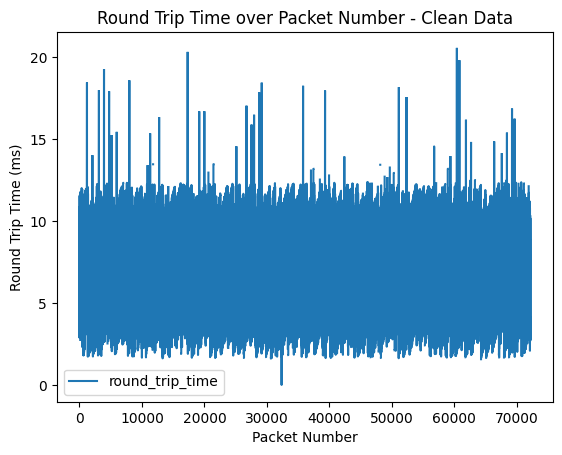

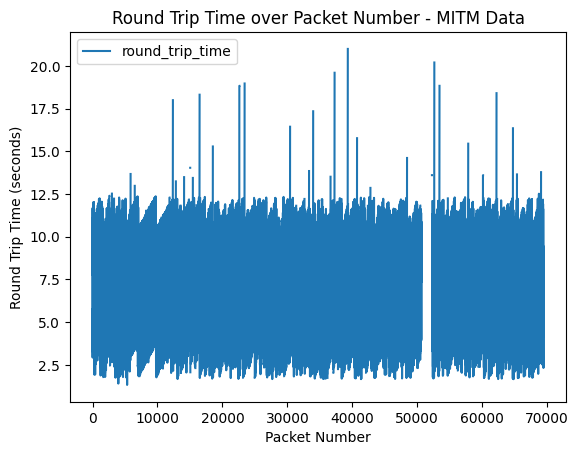

In [43]:
# Convert seconds to milliseconds for better readability
clean_data['round_trip_time'] = clean_data['round_trip_time'] * 1000
mitm_data['round_trip_time'] = mitm_data['round_trip_time'] * 1000

# Plot clean data
clean_data.plot(kind='line', x='packet_number', y='round_trip_time', title='Round Trip Time over Packet Number - Clean Data')
plt.xlabel('Packet Number')
plt.ylabel('Round Trip Time (ms)')
plt.show()


# Plot MITM data
mitm_data.plot(kind='line', x='packet_number', y='round_trip_time', title='Round Trip Time over Packet Number - MITM Data')
plt.xlabel('Packet Number')
plt.ylabel('Round Trip Time (seconds)')
plt.show()

# Inter-Arrival Time detection and plotting


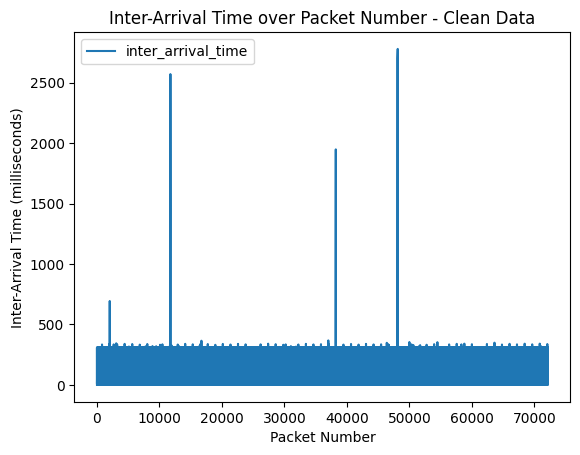

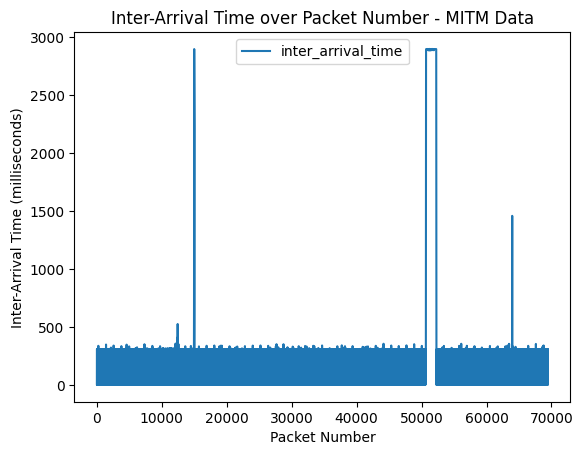

In [44]:
# Convert seconds to milliseconds for better readability
clean_data['inter_arrival_time'] = clean_data['inter_arrival_time'] * 1000
mitm_data['inter_arrival_time'] = mitm_data['inter_arrival_time'] * 1000

clean_data.plot(kind='line', x='packet_number', y='inter_arrival_time', title='Inter-Arrival Time over Packet Number - Clean Data')
plt.xlabel('Packet Number')
plt.ylabel('Inter-Arrival Time (milliseconds)')
plt.show()

mitm_data.plot(kind='line', x='packet_number', y='inter_arrival_time', title='Inter-Arrival Time over Packet Number - MITM Data')
plt.xlabel('Packet Number')
plt.ylabel('Inter-Arrival Time (milliseconds)')
plt.show()

# Flow Packet Count detection and plotting

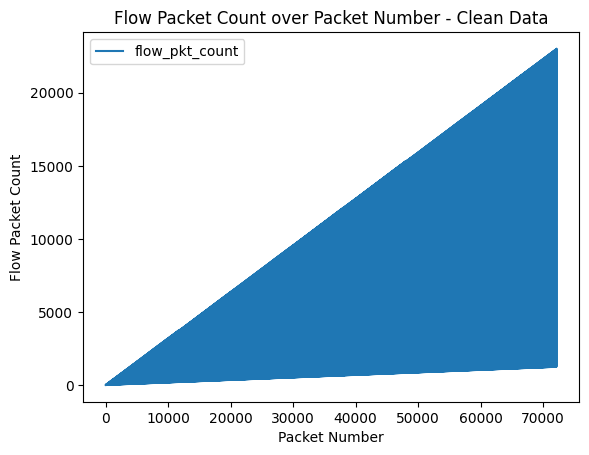

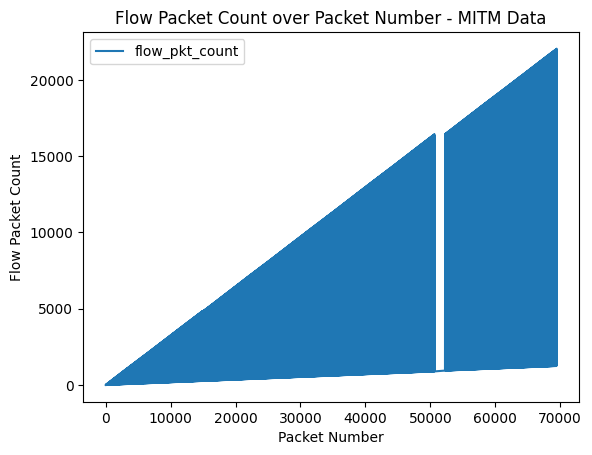

In [45]:
clean_data.plot(kind='line', x='packet_number', y='flow_pkt_count', title='Flow Packet Count over Packet Number - Clean Data')
plt.xlabel('Packet Number')
plt.ylabel('Flow Packet Count')
plt.show()

mitm_data.plot(kind='line', x='packet_number', y='flow_pkt_count', title='Flow Packet Count over Packet Number - MITM Data')
plt.xlabel('Packet Number')
plt.ylabel('Flow Packet Count')
plt.show()

# Requests Per Second detection and plotting

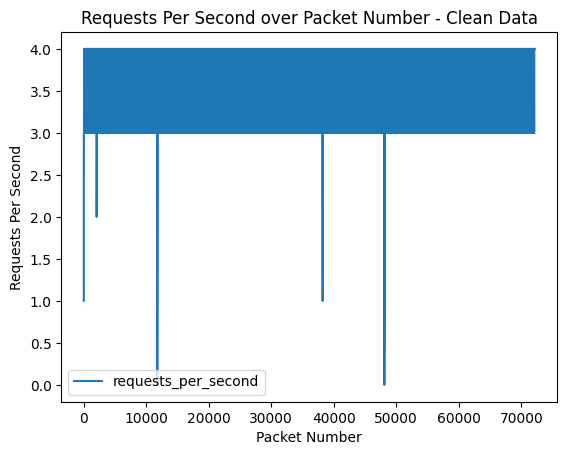

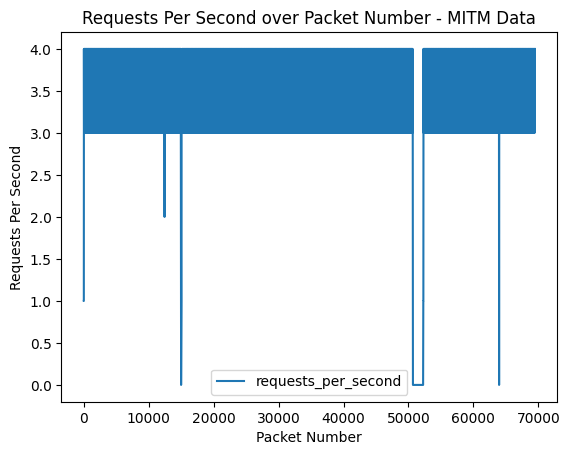

In [46]:
clean_data.plot(kind='line', x='packet_number', y='requests_per_second', title='Requests Per Second over Packet Number - Clean Data')
plt.xlabel('Packet Number')
plt.ylabel('Requests Per Second')
plt.show()

mitm_data.plot(kind='line', x='packet_number', y='requests_per_second', title='Requests Per Second over Packet Number - MITM Data')
plt.xlabel('Packet Number')
plt.ylabel('Requests Per Second')
plt.show()

# Function Codes detection and plotting

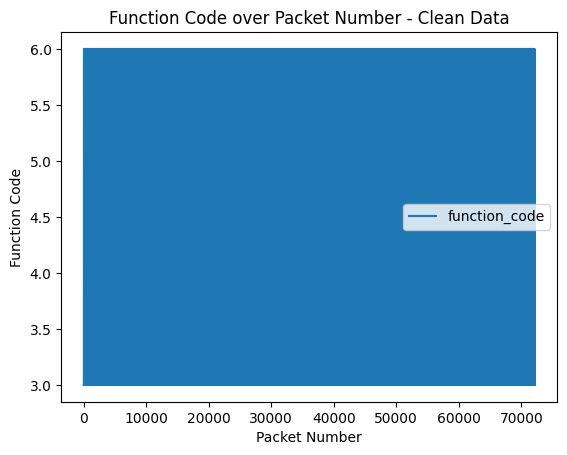

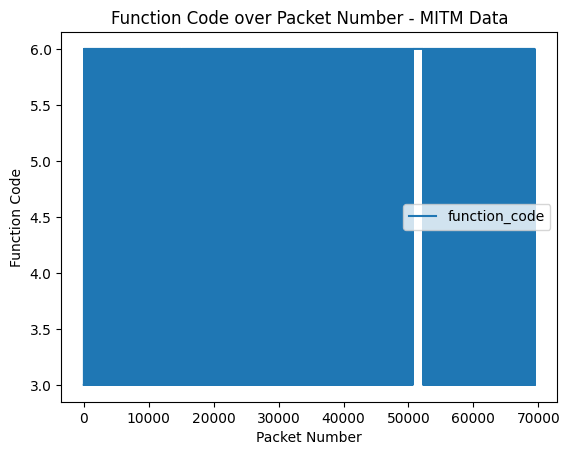

In [47]:
clean_data.plot(kind='line', x='packet_number', y='function_code', title='Function Code over Packet Number - Clean Data')
plt.xlabel('Packet Number')
plt.ylabel('Function Code')
plt.show()

mitm_data.plot(kind='line', x='packet_number', y='function_code', title='Function Code over Packet Number - MITM Data')
plt.xlabel('Packet Number')
plt.ylabel('Function Code')
plt.show()

# Isolation Forest for Anomaly Detection on features

In [48]:
# Create time-series features using rolling windows
window_size = 10  # Adjust based on your data

features_to_use = ['round_trip_time', 'inter_arrival_time', 'requests_per_second']

# Work on copies to preserve original data
clean_ts = clean_data.copy()
mitm_ts = mitm_data.copy()

# First, fill any existing NaN in base features
for df in [clean_ts, mitm_ts]:
    for col in features_to_use:
        df[col] = df[col].fillna(df[col].median())

# Create rolling/lag features
for df in [clean_ts, mitm_ts]:
    for col in features_to_use:
        df[f'{col}_rolling_mean'] = df[col].rolling(window=window_size, min_periods=1).mean()
        df[f'{col}_rolling_std'] = df[col].rolling(window=window_size, min_periods=1).std().fillna(0)
        df[f'{col}_lag1'] = df[col].shift(1).fillna(df[col].iloc[0])
        df[f'{col}_diff'] = df[col].diff().fillna(0)

# Select features for Isolation Forest
feature_cols = [col for col in clean_ts.columns if any(x in col for x in ['rolling', 'lag', 'diff'])]
feature_cols += features_to_use

print(f"Clean data shape: {clean_ts.shape}")
print(f"MITM data shape: {mitm_ts.shape}")
print(f"\nFeatures used for Isolation Forest ({len(feature_cols)}):")
print(feature_cols)

Clean data shape: (24245, 45)
MITM data shape: (23283, 45)

Features used for Isolation Forest (17):
['rolling_iat_mean', 'rolling_iat_std', 'round_trip_time_rolling_mean', 'round_trip_time_rolling_std', 'round_trip_time_lag1', 'round_trip_time_diff', 'inter_arrival_time_rolling_mean', 'inter_arrival_time_rolling_std', 'inter_arrival_time_lag1', 'inter_arrival_time_diff', 'requests_per_second_rolling_mean', 'requests_per_second_rolling_std', 'requests_per_second_lag1', 'requests_per_second_diff', 'round_trip_time', 'inter_arrival_time', 'requests_per_second']


In [ ]:
# Train Isolation Forest on CLEAN data only (learn normal behavior)
X_clean = clean_ts[feature_cols]

iso_forest = IsolationForest(contamination=0.01, random_state=42, n_estimators=200
iso_forest.fit(X_clean)

# Predict on both datasets
clean_ts['anomaly'] = iso_forest.predict(X_clean)
clean_ts['anomaly_score'] = iso_forest.decision_function(X_clean)

X_mitm = mitm_ts[feature_cols]
mitm_ts['anomaly'] = iso_forest.predict(X_mitm)
mitm_ts['anomaly_score'] = iso_forest.decision_function(X_mitm)

# Count anomalies
print(f"Clean data anomalies: {(clean_ts['anomaly'] == -1).sum()} / {len(clean_ts)} ({(clean_ts['anomaly'] == -1).mean()*100:.2f}%)")
print(f"MITM data anomalies: {(mitm_ts['anomaly'] == -1).sum()} / {len(mitm_ts)} ({(mitm_ts['anomaly'] == -1).mean()*100:.2f}%)")

Clean data anomalies: 243 / 24245 (1.00%)
MITM data anomalies: 287 / 23283 (1.23%)


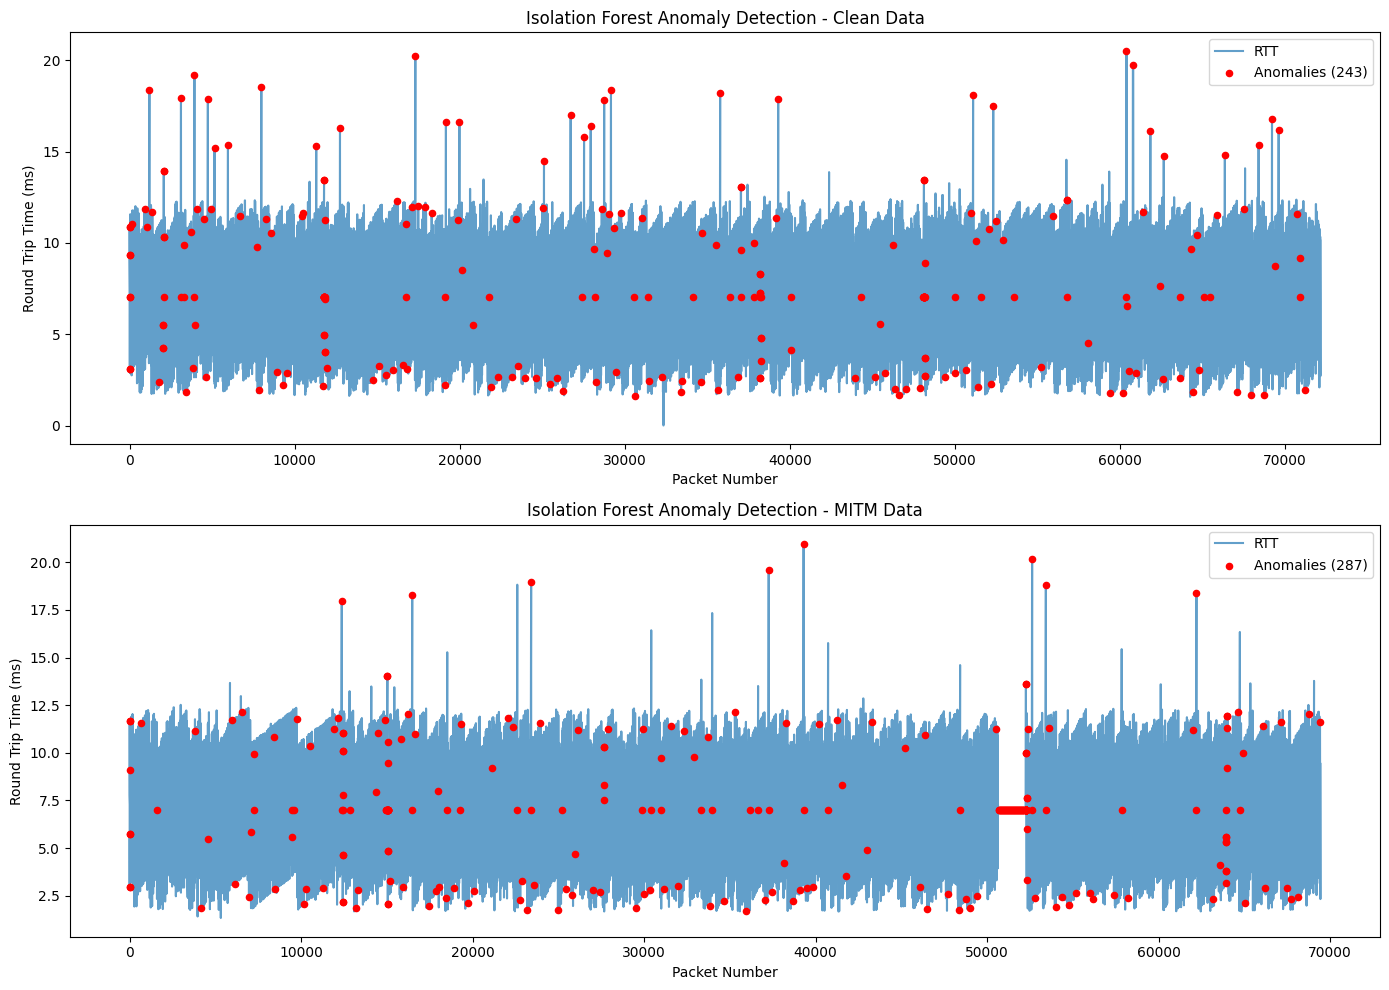

In [50]:
# Visualize anomalies on Clean Data
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Clean data
ax1 = axes[0]
ax1.plot(clean_ts['packet_number'], clean_ts['round_trip_time'], label='RTT', alpha=0.7)
anomalies_clean = clean_ts[clean_ts['anomaly'] == -1]
ax1.scatter(anomalies_clean['packet_number'], anomalies_clean['round_trip_time'], 
            color='red', label=f'Anomalies ({len(anomalies_clean)})', zorder=5, s=20)
ax1.set_xlabel('Packet Number')
ax1.set_ylabel('Round Trip Time (ms)')
ax1.set_title('Isolation Forest Anomaly Detection - Clean Data')
ax1.legend()

# MITM data
ax2 = axes[1]
ax2.plot(mitm_ts['packet_number'], mitm_ts['round_trip_time'], label='RTT', alpha=0.7)
anomalies_mitm = mitm_ts[mitm_ts['anomaly'] == -1]
ax2.scatter(anomalies_mitm['packet_number'], anomalies_mitm['round_trip_time'], 
            color='red', label=f'Anomalies ({len(anomalies_mitm)})', zorder=5, s=20)
ax2.set_xlabel('Packet Number')
ax2.set_ylabel('Round Trip Time (ms)')
ax2.set_title('Isolation Forest Anomaly Detection - MITM Data')
ax2.legend()

plt.tight_layout()
plt.show()

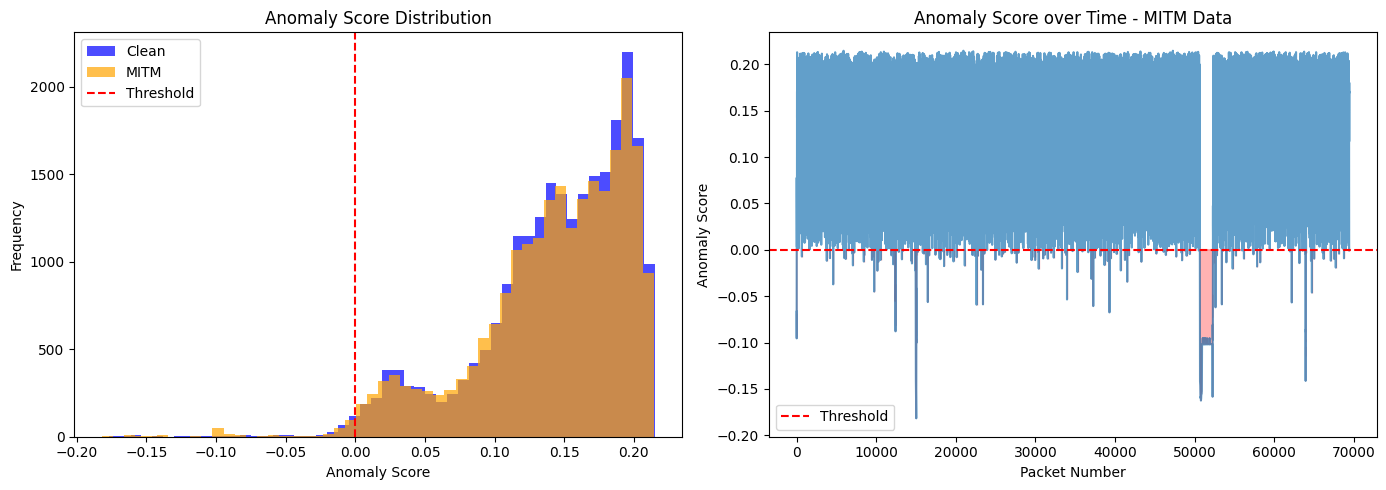

In [51]:
# Compare anomaly score distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of anomaly scores
axes[0].hist(clean_ts['anomaly_score'], bins=50, alpha=0.7, label='Clean', color='blue')
axes[0].hist(mitm_ts['anomaly_score'], bins=50, alpha=0.7, label='MITM', color='orange')
axes[0].axvline(x=0, color='red', linestyle='--', label='Threshold')
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Anomaly Score Distribution')
axes[0].legend()

# Anomaly score over time for MITM
axes[1].plot(mitm_ts['packet_number'], mitm_ts['anomaly_score'], alpha=0.7)
axes[1].axhline(y=0, color='red', linestyle='--', label='Threshold')
axes[1].fill_between(mitm_ts['packet_number'], mitm_ts['anomaly_score'], 0, 
                      where=(mitm_ts['anomaly_score'] < 0), alpha=0.3, color='red')
axes[1].set_xlabel('Packet Number')
axes[1].set_ylabel('Anomaly Score')
axes[1].set_title('Anomaly Score over Time - MITM Data')
axes[1].legend()

plt.tight_layout()
plt.show()